In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Python\Pandas\women_clothing_ecommerce_sales.csv")
df.head()

,order_id,order_date,sku,color,size,unit_price,quantity,revenue
0,1,2022/6/1 16:05:00,708,Dark Blue,2XL,298,1,298
1,1,2022/6/1 16:05:00,89,Dark Blue,2XL,258,1,258
2,2,2022/6/10 17:03:00,bobo,Cream,One Size,228,1,228
3,3,2022/6/10 19:59:00,799,Dark Blue,XL,264,1,264
4,4,2022/6/11 11:42:00,799,Dark Blue,M,264,1,264


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   order_id    527 non-null    int64 
 1   order_date  527 non-null    object
 2   sku         527 non-null    object
 3   color       527 non-null    object
 4   size        490 non-null    object
 5   unit_price  527 non-null    int64 
 6   quantity    527 non-null    int64 
 7   revenue     527 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 33.1+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

order_id       0
order_date     0
sku            0
color          0
size          37
unit_price     0
quantity       0
revenue        0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

order_id      0
order_date    0
sku           0
color         0
size          0
unit_price    0
quantity      0
revenue       0
dtype: int64

In [11]:
df.describe()

,order_id,unit_price,quantity,revenue
count,490.000000,490.000000,490.000000,490.000000
mean,117.087755,276.153061,1.012245,279.434694
std,72.596811,35.211936,0.110089,45.858376
min,1.000000,191.000000,1.000000,191.000000
25%,57.250000,266.000000,1.000000,266.000000
50%,111.500000,278.000000,1.000000,278.000000
75%,165.750000,288.000000,1.000000,288.000000
max,273.000000,899.000000,2.000000,899.000000


In [12]:
df["size"].unique()

array(['2XL', 'One Size', 'XL', 'M', '3XL', 'L', '4XL', 'S', 'One SIze'],
      dtype=object)

In [ ]:
#df.replace({'One SIze': 'One Size'}, inplace=True)

In [14]:
df1 = df[(df["size"] != 'One SIze')]

In [15]:
df1["size"].unique()

array(['2XL', 'One Size', 'XL', 'M', '3XL', 'L', '4XL', 'S'], dtype=object)

In [17]:
df1.groupby("size")["revenue"].max()

size
2XL         315
3XL         315
4XL         899
L           576
M           576
One Size    576
S           227
XL          576
Name: revenue, dtype: int64

In [16]:
import matplotlib.pyplot as plt 

Text(0.5, 1.0, 'size vs max revenue')

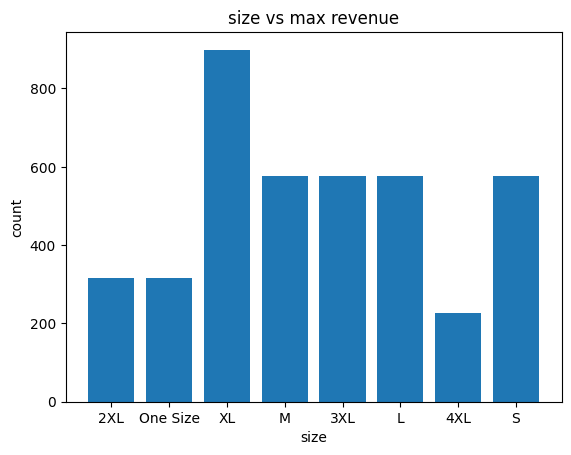

In [18]:
plt.bar(df1["size"].unique(), df1.groupby("size")["revenue"].max())
plt.xlabel("size")
plt.ylabel("count")
plt.title("size vs max revenue")

In [19]:
df1["color"].unique()

array(['Dark Blue', 'Cream', 'Navy Blue', 'Blue', 'Light Gray',
       'Mid Wash', 'Light Blue', 'Dark Wash', 'Thin Blue', 'Grey Wash',
       'Thin Black', '922 Black', '922 Army green', 'Gray Stripes',
       '920 Navy blue', 'Light Wash', 'Blue Stripes', 'Black Stripes',
       'Black', 'Matcha', 'Maroon', 'Pink', 'Red Orange', 'White'],
      dtype=object)

In [20]:
df1.groupby("color")["quantity"].max()

color
920 Navy blue     1
922 Army green    1
922 Black         1
Black             2
Black Stripes     1
Blue              1
Blue Stripes      1
Cream             2
Dark Blue         2
Dark Wash         1
Gray Stripes      1
Grey Wash         1
Light Blue        1
Light Gray        1
Light Wash        1
Maroon            1
Matcha            1
Mid Wash          1
Navy Blue         1
Pink              1
Red Orange        1
Thin Black        1
Thin Blue         1
White             1
Name: quantity, dtype: int64

In [22]:
df1["color"].value_counts()

color
Dark Blue         397
Light Blue         25
Black              12
Grey Wash           9
Mid Wash            8
Dark Wash           5
Blue                4
Navy Blue           3
Thin Blue           3
Cream               2
White               2
Blue Stripes        2
Matcha              2
Light Gray          1
Thin Black          1
922 Black           1
Light Wash          1
920 Navy blue       1
Gray Stripes        1
922 Army green      1
Black Stripes       1
Maroon              1
Pink                1
Red Orange          1
Name: count, dtype: int64

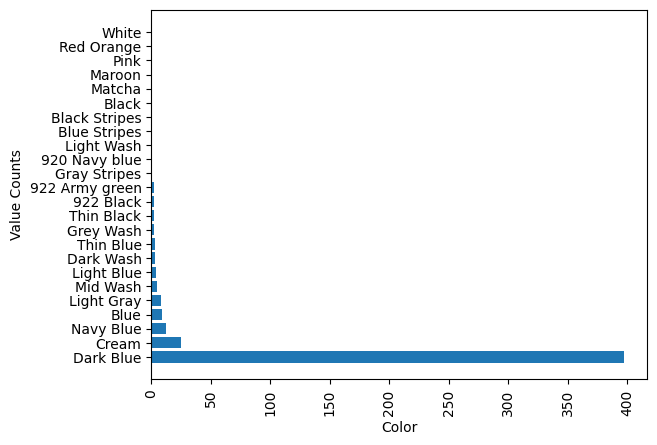

In [26]:
plt.barh(df1["color"].unique(), df1["color"].value_counts())
plt.xlabel("Color")
plt.ylabel("Value Counts")
plt.xticks(rotation=90)
plt.show()

In [33]:
df1["size"].unique()

array(['2XL', 'One Size', 'XL', 'M', '3XL', 'L', '4XL', 'S'], dtype=object)

In [29]:
df1.groupby("size")["unit_price"].mean()

size
2XL         288.883721
3XL         282.525000
4XL         356.111111
L           275.538462
M           276.815217
One Size    251.422222
S           227.000000
XL          276.310976
Name: unit_price, dtype: float64

([<matplotlib.patches.Wedge at 0x2ccd277b750>,
 [Text(1.0105194477681032, 0.4345692645395529, '2XL'),
  Text(0.38886720693637966, 1.0289714745169076, 'One Size'),
  Text(-0.5622630221721641, 0.9454418511457088, 'XL'),
  Text(-1.088256752234275, 0.1603035907785853, 'M'),
  Text(-0.8886406618257333, -0.6483191915637875, '3XL'),
  Text(-0.2162335640873018, -1.078537456819235, 'L'),
  Text(0.5028189096408493, -0.9783522597242711, '4XL'),
  Text(1.0180430034765178, -0.41663946413237324, 'S')],
 [Text(0.5511924260553289, 0.23703778065793793, '12.9%'),
  Text(0.21210938560166162, 0.5612571679183131, '12.6%'),
  Text(-0.3066889211848167, 0.5156955551703866, '15.9%'),
  Text(-0.5935945921277862, 0.0874383222428647, '12.3%'),
  Text(-0.4847130882685817, -0.35362864994388404, '12.4%'),
  Text(-0.1179455804112555, -0.5882931582650371, '11.3%'),
  Text(0.2742648598040996, -0.5336466871223297, '10.2%'),
  Text(0.5552961837144641, -0.22725788952674902, '12.4%')])

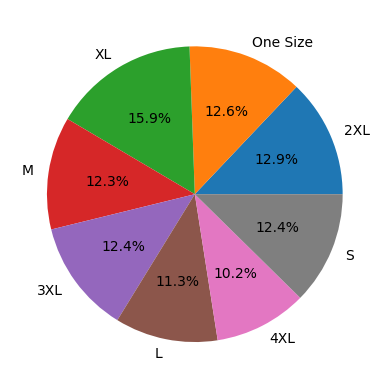

In [41]:
plt.pie(df1.groupby("size")["unit_price"].mean(), labels=df1["size"].unique(), autopct="%1.1f%%")

In [38]:
#SKU vs SIZE
df1["sku"].info()

<class 'pandas.core.series.Series'>
Index: 485 entries, 0 to 526
Series name: sku
Non-Null Count  Dtype 
--------------  ----- 
485 non-null    object
dtypes: object(1)
memory usage: 7.6+ KB


In [43]:
df1["sku"].fillna(0, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_12844\111693704.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["sku"].fillna(0, inplace=True)


In [48]:
df1['month'] = pd.to_datetime(df1['order_date']).dt.month

C:\Users\Admin\AppData\Local\Temp\ipykernel_12844\4064232604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['month'] = pd.to_datetime(df1['order_date']).dt.month


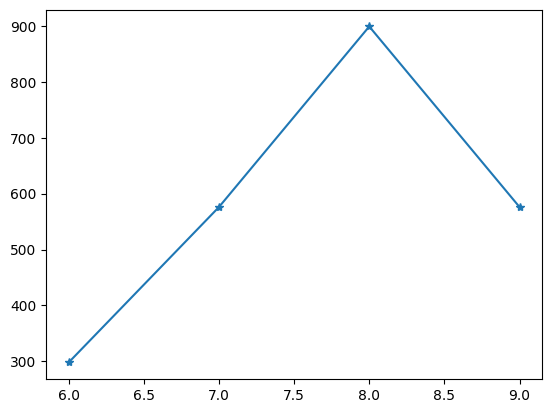

In [ ]:
plt.plot(df1['month'].unique(), df1.groupby("month")["revenue"].max(), marker="*", label="revenue")

In [52]:
df1.groupby("month")["revenue"].max()

month
6    298
7    576
8    899
9    576
Name: revenue, dtype: int64

In [54]:
df1["month"].unique()

array([6, 7, 8, 9], dtype=int32)

In [57]:
df1.groupby("month")["unit_price"].max()

month
6    298
7    315
8    899
9    318
Name: unit_price, dtype: int64

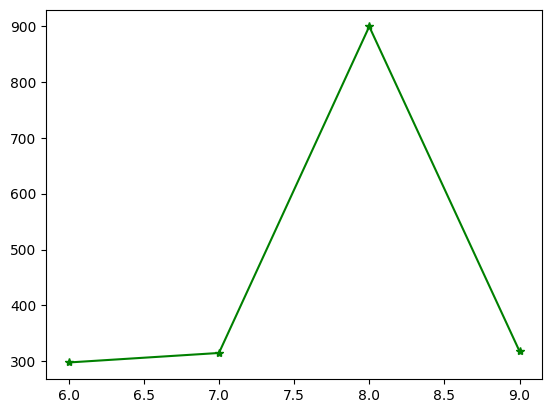

In [59]:
plt.plot(df1["month"].unique(), df1.groupby("month")["unit_price"].max(), marker="*", color="g")

C:\Users\Admin\AppData\Local\Temp\ipykernel_12844\3593008666.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df1["month"].unique(), df1.groupby("month")["revenue"].max(),  alpha=0.4,edgecolor="r", linewidth=2,  s=90, cmap="viridis" , label="revenue")


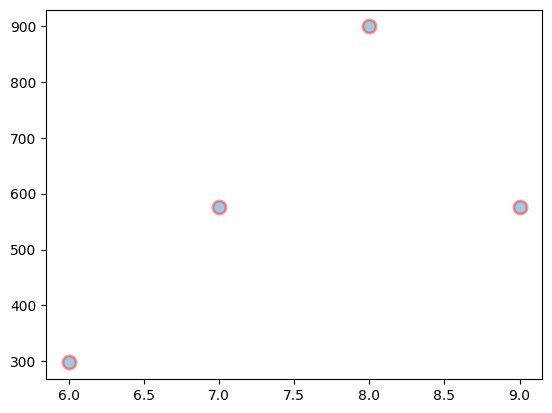

In [66]:
plt.scatter(df1["month"].unique(), df1.groupby("month")["revenue"].max(),  alpha=0.4,edgecolor="r", linewidth=2,  s=90, cmap="viridis" , label="revenue")

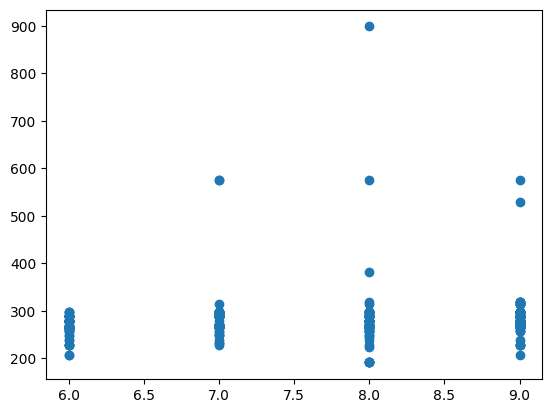

In [67]:
plt.scatter(df1['month'], df1['revenue'])

In [68]:
df1["order_date"].apply(lambda x: x.split("/")[1] )

0      6
1      6
2      6
3      6
4      6
      ..
522    9
523    9
524    9
525    9
526    9
Name: order_date, Length: 485, dtype: object

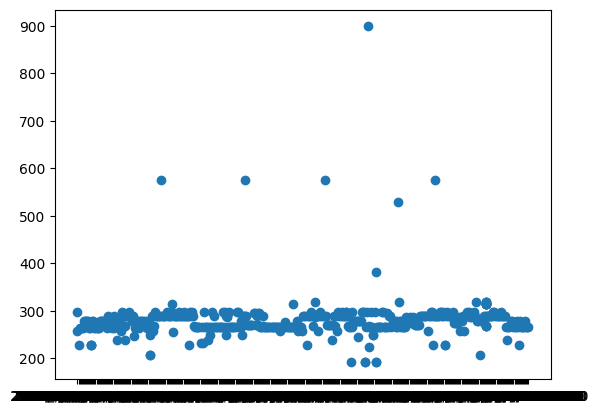

In [69]:
plt.scatter(df1["order_date"], df1["revenue"])

In [71]:
df1["sku"].unique()

array(['708', '89', 'bobo', '799', '897', '9699', '127', '1719', '3799',
       '229', '2499', '79', '29', '1499', '628', '61399', '218', '8499',
       '539'], dtype=object)

In [80]:
df1[df1["sku"] != 'bobo']


,order_id,order_date,sku,color,size,unit_price,quantity,revenue,month
0,1,2022/6/1 16:05:00,708,Dark Blue,2XL,298,1,298,6
1,1,2022/6/1 16:05:00,89,Dark Blue,2XL,258,1,258,6
3,3,2022/6/10 19:59:00,799,Dark Blue,XL,264,1,264,6
4,4,2022/6/11 11:42:00,799,Dark Blue,M,264,1,264,6
5,5,2022/6/11 14:46:00,799,Dark Blue,XL,264,1,264,6
...,...,...,...,...,...,...,...,...,...
522,171,2022/9/9 6:27:00,799,Dark Blue,M,265,1,265,9
523,172,2022/9/9 7:18:00,708,Dark Blue,4XL,278,1,278,9
524,173,2022/9/9 7:22:00,799,Dark Blue,M,265,1,265,9
525,174,2022/9/9 8:25:00,799,Dark Blue,L,265,1,265,9


In [78]:
df1["sku"].unique()

array(['708', '89', 'bobo', '799', '897', '9699', '127', '1719', '3799',
       '229', '2499', '79', '29', '1499', '628', '61399', '218', '8499',
       '539'], dtype=object)

In [81]:
df1["sku"] = df1["sku"].astype(int)

ValueError: invalid literal for int() with base 10: 'bobo'